In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import nn4n
import seaborn as sns
from scipy.optimize import curve_fit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Generate experience vectors (trial, time, channel) 

In [2]:
ntrial, ntime, nchannel = 1024, 200, 100

Generate 100 temporal hannels sampling source

In [3]:
# Generate 100 smooth temporal series (T=500, n=100) sampling source
from scipy.ndimage import gaussian_filter1d
sampleT = 500
smooth_sigma = 5
lower, upper = 1, 5
raw_series = np.random.uniform(low=lower, high=upper, size=(nchannel, sampleT))

# Apply Gaussian smoothing to each series
smooth_series = np.array([gaussian_filter1d(ts, sigma=smooth_sigma) for ts in raw_series])

print(smooth_series.shape)  # (channel = 100, sample time = 500)

(100, 500)


Text(0.5, 0, 'Time Steps')

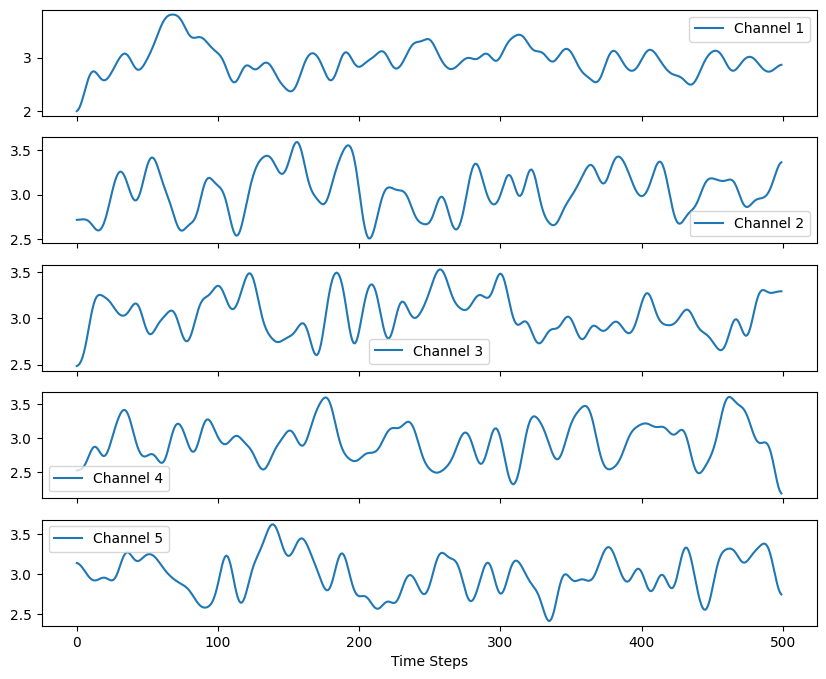

In [4]:
# Plot a few example channels
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
for i in range(5):
    axes[i].plot(smooth_series[i], label=f'Channel {i+1}')
    axes[i].legend()
plt.xlabel('Time Steps')

In [5]:
EVs = np.zeros((ntrial, ntime, nchannel))
for ch in range(nchannel):
    start_idx = np.random.randint(0, sampleT-ntime+1)
    segment = smooth_series[ch, start_idx:start_idx+ntime]
    for tr in range(ntrial):
        EVs[tr, :, ch] = segment 

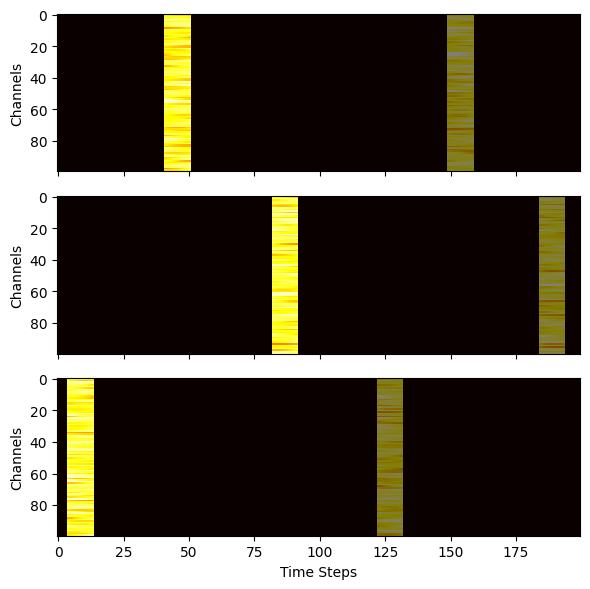

In [6]:
mask_EVs = EVs.copy()

np.random.seed(42)

# Long masking
mask_start_idx = np.random.randint(0, ntime/2, size=ntrial)
mask_length = np.random.randint(90, 110, size=ntrial)
for tr in range(ntrial):
    
    mask_EVs[tr, :mask_start_idx[tr]-10, :] = 0 # Mask the start
    mask_EVs[tr, mask_start_idx[tr]:mask_start_idx[tr]+mask_length[tr], :] = 0 # Mask the middle
    mask_EVs[tr, mask_start_idx[tr]+mask_length[tr]:, :] = 0 # Mask the end
    
    EVs[tr, :mask_start_idx[tr]-10, :] = 0 # Mask the start
    EVs[tr, mask_start_idx[tr]:mask_start_idx[tr]+mask_length[tr], :] = 0 # Mask the middle
    EVs[tr, mask_start_idx[tr]+mask_length[tr]+10:, :] = 0 # Mask the end

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
for i in range(3):
    axes[i].imshow(mask_EVs[i].T, aspect='auto', cmap='hot', interpolation='nearest')
    axes[i].imshow(EVs[i].T, aspect='auto', cmap='hot', interpolation='nearest', alpha=0.5)
    axes[i].set_ylabel('Channels')
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [7]:
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.3,    # Maximum masking ratio
                m_min=0.1,    # Minimum masking ratio
                sigma_t=0.5,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=0,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )
mask_EVs = mask.mask(mask_EVs).numpy()

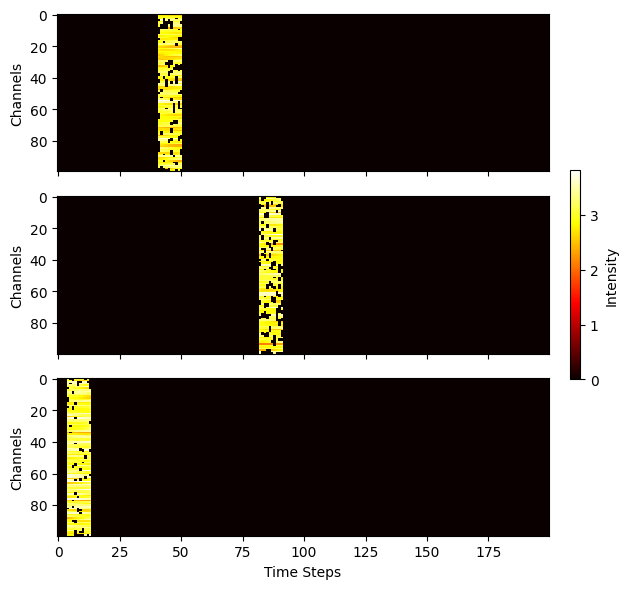

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
for i in range(3):
    axes[i].imshow(mask_EVs[i].T, aspect='auto', cmap='hot', interpolation='nearest')
    axes[i].set_ylabel('Channels')
plt.xlabel('Time Steps')
plt.tight_layout()
# Plot colorbar
cbar = plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Intensity')
plt.show()

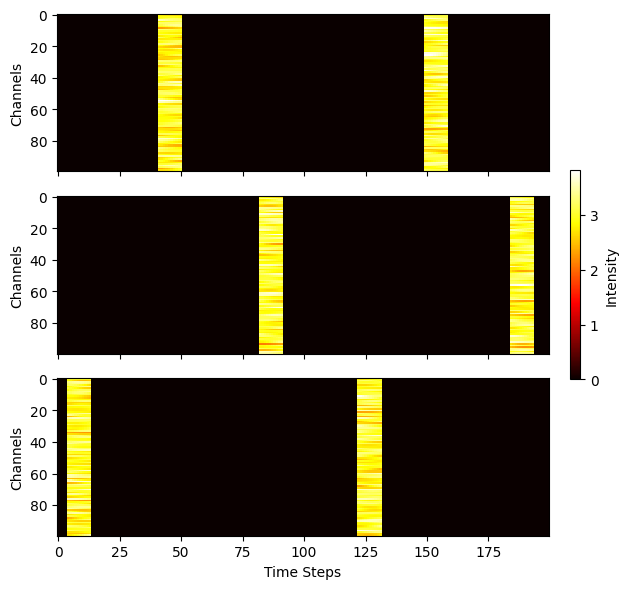

In [9]:
# Plot the labels
fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
for i in range(3):
    axes[i].imshow(EVs[i].T, aspect='auto', cmap='hot', interpolation='nearest')
    axes[i].set_ylabel('Channels')
plt.xlabel('Time Steps')
plt.tight_layout()
# Plot colorbar
cbar = plt.colorbar(axes[0].images[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Intensity')
plt.show()

In [10]:
# # Gaussian smooth the EVs and mask_EVs
# for i in range(ntrial):
#     EVs[i] = gaussian_filter1d(EVs[i], sigma=2, axis=0)
#     mask_EVs[i] = gaussian_filter1d(mask_EVs[i], sigma=2, axis=0)

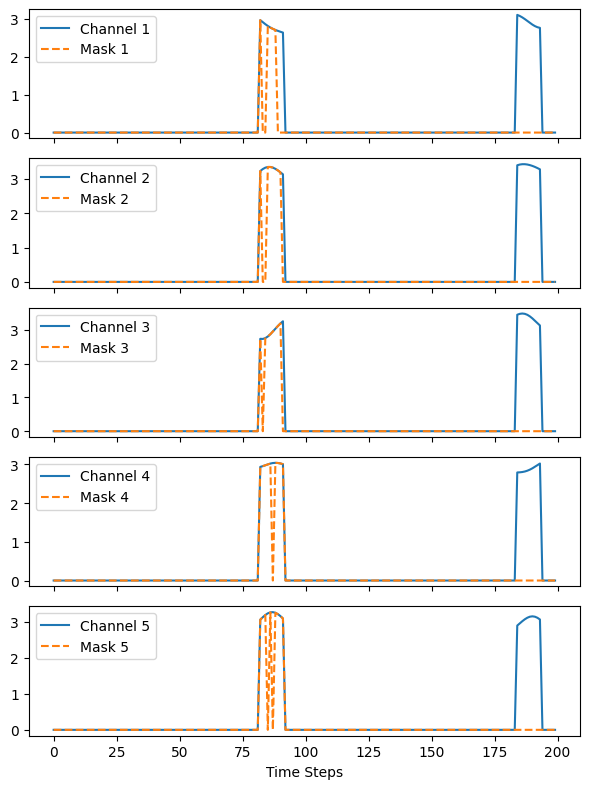

In [11]:
# Plot a few channels in one trial
num_chan = 5
fig, axes = plt.subplots(num_chan, 1, figsize=(6, 8), sharex=True)
for i in range(num_chan):
    axes[i].plot(EVs[1, :, i], label=f'Channel {i+1}')
    axes[i].plot(mask_EVs[1, :, i], label=f'Mask {i+1}', linestyle='--')
    axes[i].legend()
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [12]:
labels = EVs.copy()
inputs = mask_EVs.copy()

inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
labels = torch.tensor(labels, dtype=torch.float32).to(device)

print(inputs.shape, labels.shape)  

torch.Size([1024, 200, 100]) torch.Size([1024, 200, 100])


### Train the RNN

In [13]:
num_neuron = 512


dt = 0.1 
taus = np.logspace(-1, 1, num_neuron) # tau in [0.1, 10]  
custom_alpha = 1 - np.exp(-dt / taus) 
print(custom_alpha.min(), custom_alpha.max())


model_cfg = {
            "input_dim":    inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   inputs.shape[2],
            "alpha":        custom_alpha, # NEW
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

0.009950166250831893 0.6321205588285577


In [14]:
# Create DataLoader for training and testing
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(inputs, labels)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [15]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(2000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    if  len(losses) > 50  and abs(losses[-1] - losses[-50]) < 1e-4 and losses[-1] < 0.012: # and len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 1/2000 [00:00<19:37,  1.70it/s]

Epoch 0 Loss 0.6636766791343689
tensor(0.6281, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0356, device='cuda:0', grad_fn=<MulBackward0>)


 25%|██▌       | 501/2000 [03:26<10:16,  2.43it/s]

Epoch 500 Loss 0.10677902400493622
tensor(0.0957, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0111, device='cuda:0', grad_fn=<MulBackward0>)


 50%|█████     | 1001/2000 [06:52<06:50,  2.43it/s]

Epoch 1000 Loss 0.06531436741352081
tensor(0.0541, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0112, device='cuda:0', grad_fn=<MulBackward0>)


 75%|███████▌  | 1501/2000 [10:18<03:25,  2.43it/s]

Epoch 1500 Loss 0.05756792798638344
tensor(0.0464, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0112, device='cuda:0', grad_fn=<MulBackward0>)


100%|██████████| 2000/2000 [13:43<00:00,  2.43it/s]

Training complete.


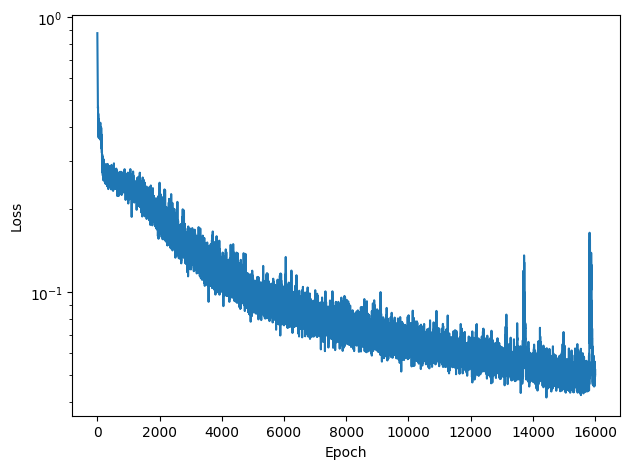

In [16]:
plt.figure()
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

In [17]:
# Generate 64 test trials
test_idx = np.random.randint(0, ntrial, size=64)
test_inputs = inputs[test_idx]
test_labels = labels[test_idx]

In [18]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  test_outputs.shape)
print('hidden states:', hidden_states.shape)

test outputs: (64, 200, 100)
hidden states: (64, 200, 512)


In [82]:
plot_idx = 37

### Test the widening effect

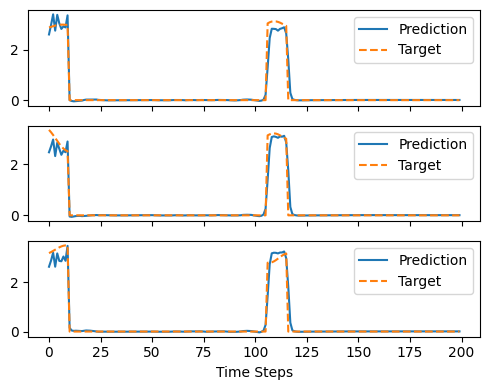

In [95]:
# Plot a few test trials
fig, axes = plt.subplots(3, 1, figsize=(5, 4), sharex=True)
for i in range(3):
    # axes[i].plot(test_inputs[plot_idx, :, i].cpu().numpy(), color='C2', linestyle=':', label='Input')
    axes[i].plot(test_outputs[plot_idx, :, i], color='C0',label=f'Prediction')
    axes[i].plot(test_labels[plot_idx, :, i].cpu().numpy(), color='C1', linestyle='--', label='Target')
    axes[i].legend()
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [96]:
def plt_hs(hs, min_fr=0.1, fig=None, ax=None):

    time_points = hs.shape[0]
    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    num_neurons = norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, num_neurons, 0]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))
    
    return norm_hs, fig, ax

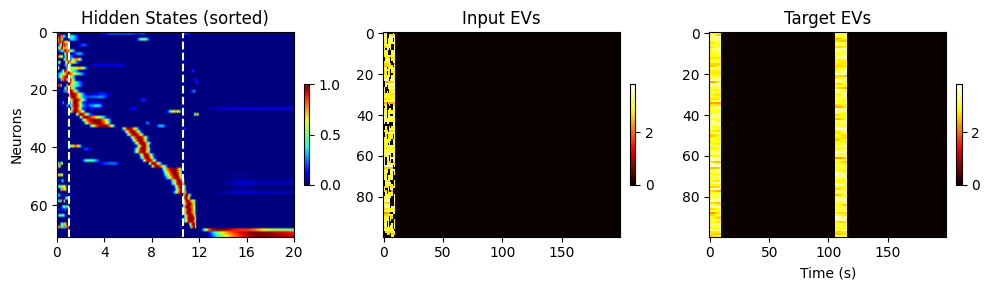

In [97]:
fig, axes = plt.subplots(1,3, figsize=(10, 3))

norm_hs, fig, axes[0] = plt_hs(hidden_states[plot_idx], min_fr=0.1, fig=fig, ax=axes[0])
# Plot vertical lines at mask start and end
axes[0].axvline(x=mask_start_idx[test_idx[plot_idx]]/10, color='w', linestyle='--',)
axes[0].axvline(x=(mask_start_idx[test_idx[plot_idx]]+mask_length[test_idx[plot_idx]])/10, 
                color='w', linestyle='--')
axes[0].set_title('Hidden States (sorted)')
# Plot colorbar
cbar = plt.colorbar(axes[0].images[0], ax=axes[0], orientation='vertical', fraction=0.02, pad=0.04)

axes[2].imshow(test_labels[plot_idx].cpu().numpy().T, aspect='auto', cmap='hot', interpolation='nearest')
axes[2].set_title('Target EVs')
axes[1].imshow(test_inputs[plot_idx].cpu().numpy().T, aspect='auto', cmap='hot', interpolation='nearest')
axes[1].set_title('Input EVs')
cbar = plt.colorbar(axes[1].images[0], ax=axes[1], orientation='vertical', fraction=0.02, pad=0.04)
cbar = plt.colorbar(axes[2].images[0], ax=axes[2], orientation='vertical', fraction=0.02, pad=0.04)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()

In [98]:
print(norm_hs.shape)
# Number of active number
print(f"Number of active neurons: {norm_hs.shape[1]}")

(200, 71)
Number of active neurons: 71


In [99]:
# Sort the norm_hs with maximum firing time
time = np.arange(norm_hs.shape[0]/10)

max_time_idx = np.argmax(norm_hs, axis=0)
max_time = max_time_idx / 10

firing_starts = np.zeros(norm_hs.shape[1])
firing_ends = np.zeros(norm_hs.shape[1])
firing_widths = np.zeros(norm_hs.shape[1])

threshold = 0.5
delta = 0.05

for i in range(norm_hs.shape[1]):
    left_half = norm_hs[:max_time_idx[i], i]
    if np.any((left_half > threshold-delta) & (left_half < threshold+delta)):
        firing_starts[i] = np.where((left_half > threshold-delta) & 
                                    (left_half < threshold+delta))[0][-1]
        # firing_starts[i] = np.where(left_half < 0.5)[0][-1]
    else:
        firing_starts[i] = np.nan

# For regions right to the max time pts, find the index where the firing rate is closest to 0.7 and between 0.65 and 0.75

for i in range(norm_hs.shape[1]):
    right_half = norm_hs[max_time_idx[i]:, i]
    if np.any((right_half > threshold-delta) & (right_half < threshold+delta)):
        firing_ends[i] = max_time_idx[i] + np.where((right_half > threshold-delta) & 
                                                    (right_half < threshold+delta))[0][0]
        # firing_ends[i] = max_time[i] + np.where((right_half > 0))[0][-1]
    else:
        firing_ends[i] = np.nan

firing_widths = firing_ends - firing_starts

# Change the unit to time (s)
max_time = max_time_idx / 10
firing_starts = firing_starts / 10
firing_ends = firing_ends / 10
firing_widths = firing_widths / 10

# Plot where not nan firing widths
not_nan_mask = ~np.isnan(firing_widths)
max_time = max_time[not_nan_mask]
firing_widths = firing_widths[not_nan_mask]
firing_starts = firing_starts[not_nan_mask]
firing_ends = firing_ends[not_nan_mask]
norm_hs = norm_hs[:, not_nan_mask]

print(max_time.shape, firing_starts.shape, firing_ends.shape, firing_widths.shape)

(23,) (23,) (23,) (23,)


1.0 10.6
7 19
Corr coeff: 0.6564366881939162


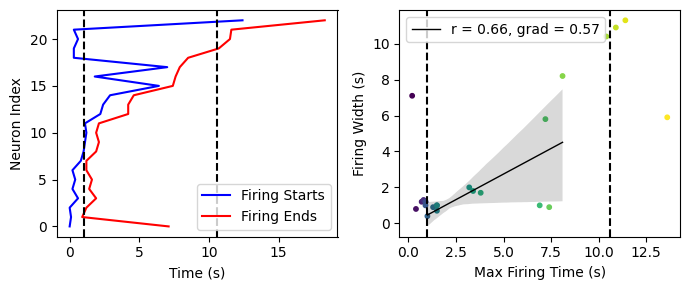

In [100]:
# Plot only firing starts and firing ends vs neuron index
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].plot(firing_starts, np.arange(firing_starts.shape[0]), color='blue', label='Firing Starts')
ax[0].plot(firing_ends,   np.arange(firing_ends.shape[0]),   color='red',  label='Firing Ends')

start_time, end_time = mask_start_idx[test_idx[plot_idx]]/10, (mask_start_idx[test_idx[plot_idx]]+mask_length[test_idx[plot_idx]])/10
print(start_time, end_time)
start_idx = np.where((max_time >= start_time) & (max_time <= end_time))[0][0]
end_idx = np.where((max_time >= start_time) & (max_time <= end_time))[0][-1]
print(start_idx, end_idx)

# Plot vertical lines at mask start and end
ax[0].axvline(x=start_time, color='k', linestyle='--',)
ax[0].axvline(x=end_time, color='k', linestyle='--',)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Neuron Index')
ax[0].legend()

# Plot firing widths vs max firing times with gradually changed colors
scatter = ax[1].scatter(max_time, firing_widths, c=range(max_time.shape[0]), cmap='viridis', s=10)
# Plot vertical lines at mask start and end
ax[1].axvline(x=start_time, color='k', linestyle='--',)
ax[1].axvline(x=end_time, color='k', linestyle='--',)
ax[1].set_xlabel('Max Firing Time (s)')
ax[1].set_ylabel('Firing Width (s)')

rval = np.corrcoef(max_time[start_idx:end_idx], 
                   firing_widths[start_idx:end_idx])[0,1]
print(f'Corr coeff: {rval}')
# Fit the linear regression line and find the gradient
def linear_model(x, a, b):
    return a * x + b
popt, pcov = curve_fit(linear_model, max_time[start_idx:end_idx], firing_widths[start_idx:end_idx])

sns.regplot(x=max_time[start_idx:end_idx], 
            y=firing_widths[start_idx:end_idx],
            scatter=False, 
            color='black',
            line_kws={"linewidth":1, "linestyle":"-"},
            ci=95,
            label=f'r = {rval:.2f}, grad = {popt[0]:.2f}')

ax[1].legend()
plt.tight_layout()
plt.show()